# 03 · Impurity and Information Gain

What is the tree actually optimizing? We look at the scoring function: Gini vs entropy (they barely differ), and the identity that ties this project to information theory — **a split's information gain is the mutual information between the split and the target**.

**Artifacts:** `outputs/figures/03_*.png`, `outputs/data/03_*.json`.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score

from src.config import load_settings
from src.datasets import moons
from src.tree.criteria import gini, entropy, mse, information_gain, mutual_information
from src.tree.splitter import best_split
from src.outputs import save_figure, save_json

SEED = load_settings().seed
X, y = moons(n_samples=400, noise=0.2, seed=SEED)

## The two impurity curves
For a binary node with class-1 fraction p: Gini = 1 − p² − (1 − p)², entropy = −p·log₂p − (1 − p)·log₂(1 − p). Same story, entropy just peaks higher.

PosixPath('/workspaces/decision_trees_101/outputs/figures/03_impurity_curves.png')

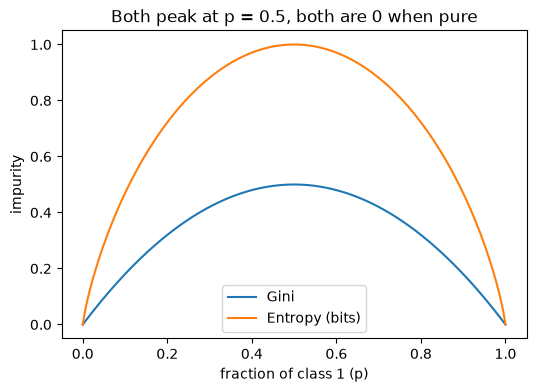

In [2]:
p = np.linspace(0, 1, 201)
gini_curve = 1 - p**2 - (1 - p)**2
with np.errstate(divide='ignore', invalid='ignore'):
    ent_curve = -(np.where(p > 0, p * np.log2(p), 0.0)
                  + np.where(p < 1, (1 - p) * np.log2(1 - p), 0.0))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(p, gini_curve, label='Gini')
ax.plot(p, ent_curve, label='Entropy (bits)')
ax.set(xlabel='fraction of class 1 (p)', ylabel='impurity', title='Both peak at p = 0.5, both are 0 when pure')
ax.legend()
save_figure(fig, '03_impurity_curves')

## Hand checks
The from-scratch functions on textbook inputs.

In [3]:
checks = {
    'gini_pure': gini(np.array([1, 1, 1])),
    'gini_balanced': gini(np.array([0, 0, 1, 1])),
    'entropy_pure_bits': entropy(np.array([1, 1, 1])),
    'entropy_balanced_bits': entropy(np.array([0, 0, 1, 1])),
    'mse_constant': mse(np.array([3.0, 3.0, 3.0])),
    'mse_0_and_2': mse(np.array([0.0, 2.0])),
}
for k, v in checks.items():
    print(f'{k:24s} = {v}')
save_json(checks, '03_hand_checks')

gini_pure                = 0.0
gini_balanced            = 0.5
entropy_pure_bits        = -0.0
entropy_balanced_bits    = 1.0
mse_constant             = 0.0
mse_0_and_2              = 1.0


PosixPath('/workspaces/decision_trees_101/outputs/data/03_hand_checks.json')

## Information gain **is** mutual information
Take the tree's chosen root split on the moons. Compute its information gain with entropy, our from-scratch mutual information, and scikit-learn's mutual information (nats → bits). All three agree.

In [4]:
split = best_split(X, y, criterion='entropy')
mask = split.left_mask
ig = information_gain(y, mask, 'entropy')
mi = mutual_information(mask, y)
mi_sklearn = mutual_info_score(mask.astype(int), y) / np.log(2)
identity = {
    'information_gain_bits': float(ig),
    'mutual_information_bits': float(mi),
    'sklearn_mutual_information_bits': float(mi_sklearn),
    'max_abs_difference': float(max(abs(ig - mi), abs(ig - mi_sklearn))),
}
print(identity)
save_json(identity, '03_info_gain_equals_mi')

{'information_gain_bits': 0.34470749865977834, 'mutual_information_bits': 0.34470749865977846, 'sklearn_mutual_information_bits': 0.34470749865977696, 'max_abs_difference': 1.3877787807814457e-15}


PosixPath('/workspaces/decision_trees_101/outputs/data/03_info_gain_equals_mi.json')

## Gini vs entropy pick (almost) the same split
Scan both criteria; the chosen feature/threshold and the shape of the gain curve barely move.

In [5]:
def best_under(criterion):
    best = None
    curves = {}
    for f in range(X.shape[1]):
        xs = np.unique(X[:, f])
        th = (xs[:-1] + xs[1:]) / 2
        g = np.array([information_gain(y, X[:, f] <= t, criterion) for t in th])
        curves[f] = (th, g)
        if best is None or g.max() > best['gain']:
            best = {'feature': f, 'threshold': float(th[np.argmax(g)]), 'gain': float(g.max())}
    return best, curves

gini_best, gini_curves = best_under('gini')
ent_best, ent_curves = best_under('entropy')
print('gini   ->', gini_best)
print('entropy->', ent_best)

gini   -> {'feature': 1, 'threshold': 0.44848262845087744, 'gain': 0.21424835233811074}
entropy-> {'feature': 1, 'threshold': 0.44848262845087744, 'gain': 0.34470749865977834}


PosixPath('/workspaces/decision_trees_101/outputs/data/03_gini_vs_entropy_split.json')

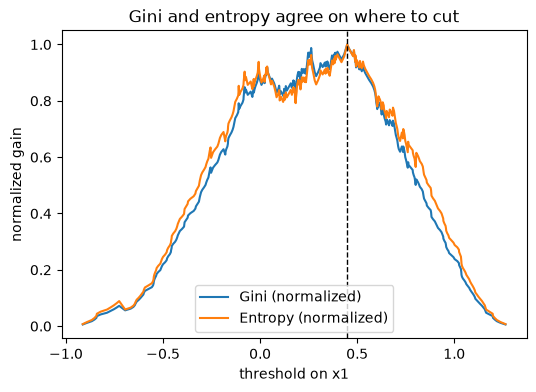

In [6]:
f = gini_best['feature']
tg, gg = gini_curves[f]
te, ge = ent_curves[f]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tg, gg / gg.max(), label='Gini (normalized)')
ax.plot(te, ge / ge.max(), label='Entropy (normalized)')
ax.axvline(gini_best['threshold'], color='k', ls='--', lw=1)
ax.set(xlabel=f'threshold on x{f}', ylabel='normalized gain', title='Gini and entropy agree on where to cut')
ax.legend()
save_figure(fig, '03_gain_gini_vs_entropy')
save_json({'gini_best': gini_best, 'entropy_best': ent_best}, '03_gini_vs_entropy_split')

## Takeaway
"The tree splits to maximize information gain" and "the tree splits to reduce uncertainty about the label" are the *same sentence*. Gini is a cheaper stand-in for entropy and picks essentially the same splits.